# Faithfulness Difference Analysis Across Layers

This notebook analyzes the differences in average faithfulness across layers between SAE faithfulness files and results validation files.

## Objective
- Load SAE faithfulness and validation results files
- Extract layer-wise faithfulness metrics
- Compare average faithfulness across layers
- Visualize differences between SAE and validation results

In [50]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [51]:
!pwd

/home/lev/code/research/ai/FourierFeaturesIsMechInterp/experiments


In [52]:
toml_mapping = None
with open("../toml_to_results_mapping.json", "r") as f:
    toml_mapping = json.load(f)

def toml_to_validation_map(config: str):
    return "../" + toml_mapping['toml_mappings'][config]['directories']['results'] + "/validation_results.json"


## File Paths Configuration

Hardcoded file paths for SAE faithfulness and validation results files.

In [ ]:
# Direction filtering configuration
# Options: "all" (include all directions), "even" (even indices only), "odd" (odd indices only)
DIRECTION_FILTER = "even"  # Change this to "all", "even", or "odd" as needed

# Examples of how this affects the analysis:
# - "all": Uses all 40 directions (default behavior, backward compatible)
# - "even": Uses only directions 0, 2, 4, 6, 8, ... (20 directions)  
# - "odd": Uses only directions 1, 3, 5, 7, 9, ... (20 directions)

TARGET_LAYER_IS_FIXED = [False, True, False, False] 
SAE_FAITHFULNESS_FILES = [
    "../outputs/sae_faithfulness_4033664173a2/sae_faithfulness_results.json",
    "../outputs/sae_faithfulness_66ed53ffb17b/sae_faithfulness_results.json",
    "../outputs/sae_faithfulness_7ff8e23c2c64/sae_faithfulness_results.json",
    "../outputs/sae_faithfulness_64b370a227ac/sae_faithfulness_results.json",
    "../outputs/sae_faithfulness_9fd4b3b873c2/sae_faithfulness_results.json",
]

# Hardcoded file paths for validation results files
VALIDATION_CONFIG_FILES = [
    [
        "configs/EleutherAI_pythia-70m-deduped-0-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_0.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_1.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_2.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_3.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_4.toml",
    ],
    [
        "configs/EleutherAI_pythia-70m-deduped-0-offset-5-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_0.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-5-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_1.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-5-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_2.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-5-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_3.toml",
        "configs/EleutherAI_pythia-70m-deduped-0-offset-5-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_4.toml"
    ],
    [
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_0.toml",
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_1.toml",
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_2.toml",
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+1-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_3.toml",
    ],
    [
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+2-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_0.toml",
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+2-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_1.toml",
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+2-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_2.toml",
        "configs/EleutherAI_pythia-70m-deduped-1-offset-+2-EleutherAI_the_pile_deduplicated-hook_resid_post/layer_3.toml",
    ]
]

print(f"SAE Faithfulness Files: {len(SAE_FAITHFULNESS_FILES)}")
print(f"Validation Results Files: {len(VALIDATION_CONFIG_FILES)}")
print(f"Direction Filter: {DIRECTION_FILTER}")

SAE Faithfulness Files: 5
Validation Results Files: 4
Direction Filter: even


## Data Loading Functions

In [54]:
from typing import Dict, Any, List
import pandas as pd

In [55]:
import os
import sys
# sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), 'src')))
from interventionfeatures.utils.config import MainConfig

def load_json_file(file_path: str) -> Dict[str, Any]:
    """
    Load a JSON file and return its contents.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        Dictionary containing the loaded JSON data
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        print(f"✓ Loaded: {file_path}")
        return data
    except Exception as e:
        print(f"✗ Error loading {file_path}: {e}")
        return {}

def load_sae_faithfulness_files(file_paths: List[str]) -> List[Dict[str, Any]]:
    """
    Load all SAE faithfulness result files.
    
    Args:
        file_paths: List of file paths to SAE faithfulness files
        
    Returns:
        List of loaded SAE faithfulness data dictionaries
    """
    sae_data = []
    for file_path in file_paths:
        data = load_json_file(file_path)
        if data:
            sae_data.append(data)
    return sae_data

def load_validation_results_files(file_paths: List[str]) -> List[Dict[str, Any]]:
    """
    Load all validation result files.
    
    Args:
        file_paths: List of file paths to validation result files
        
    Returns:
        List of loaded validation data dictionaries
    """
    validation_data = []
    config_data = []
    for config_path in file_paths:
        data = load_json_file(toml_to_validation_map(config_path))
        if data:
            validation_data.append(data)
        config = MainConfig.from_toml_file("../" + config_path)
        config_data.append(
            config.get_dict()
        )
    return validation_data, config_data

## Data Processing Functions

In [56]:
def convert_error_bars(errs: Tuple[int, int], mean_val: float):
    """Convert confidence interval bounds to error bar distances from mean"""
    lower_bound, upper_bound = errs
    return np.array([mean_val - lower_bound, upper_bound - mean_val])

def filter_directions_by_parity(directions: List[Dict[str, Any]], filter_mode: str) -> List[Dict[str, Any]]:
    """
    Filter directions based on parity mode.
    
    Args:
        directions: List of direction dictionaries
        filter_mode: "all", "even", or "odd"
        
    Returns:
        Filtered list of directions
    """
    if filter_mode == "all":
        return directions
    elif filter_mode == "even":
        return [d for d in directions if d['direction_idx'] % 2 == 0]
    elif filter_mode == "odd":
        return [d for d in directions if d['direction_idx'] % 2 == 1]
    else:
        raise ValueError(f"Invalid filter_mode: {filter_mode}. Must be 'all', 'even', or 'odd'")

def calculate_aggregated_stats(filtered_directions: List[Dict[str, Any]]) -> Tuple[float, Tuple[float, float]]:
    """
    Calculate aggregated accuracy and confidence interval from filtered directions.
    
    Args:
        filtered_directions: List of filtered direction dictionaries
        
    Returns:
        Tuple of (accuracy, (lower_ci, upper_ci))
    """
    if not filtered_directions:
        return 0.0, (0.0, 0.0)
    
    # Aggregate correct predictions and total examples
    total_correct = sum(d['correct_predictions'] for d in filtered_directions)
    total_examples = sum(d['total_examples'] for d in filtered_directions)
    
    if total_examples == 0:
        return 0.0, (0.0, 0.0)
        
    accuracy = total_correct / total_examples
    
    # Calculate confidence interval from individual direction trial accuracies
    trial_accuracies = []
    for d in filtered_directions:
        # Use the mean trial accuracy for each direction
        trial_accuracies.append(d['trial_mean_accuracy'])
    
    if len(trial_accuracies) > 1:
        # Calculate 95% CI using t-distribution
        from scipy import stats
        mean_acc = np.mean(trial_accuracies)
        sem = stats.sem(trial_accuracies)
        ci = stats.t.interval(0.95, len(trial_accuracies)-1, loc=mean_acc, scale=sem)
        return accuracy, ci
    elif len(trial_accuracies) == 1:
        # Use the individual direction's CI if only one direction
        ci = filtered_directions[0]['trial_accuracy_95_ci']
        return accuracy, (ci[0], ci[1])
    else:
        return accuracy, (accuracy, accuracy)

def extract_sae_faithfulness_by_layer(sae_data: List[Dict[str, Any]]) -> pd.DataFrame:
    """
    Extract layer-wise faithfulness data from SAE faithfulness files.

    Args:
        sae_data: List of loaded SAE faithfulness data dictionaries

    Returns:
        DataFrame with columns: ['file_idx', 'direction_idx', 'layer', 'mean_accuracy', 'data_type']
    """
    records = []

    for file_idx, data in enumerate(sae_data):
        mean_accuracy = data['overall_summary']['overall_mean_accuracy']
        record = {
            'file_idx': file_idx,
            'layer': data['sae_metadata']['layer_cutoff'],
            'mean_accuracy': mean_accuracy,
            'mean_interval': convert_error_bars(data['overall_summary']['overall_accuracy_95_ci'], mean_accuracy),
            'data_type': 'SAE',
            'file_type': 'sae_faithfulness'
        }
        records.append(record)

    return pd.DataFrame(records)


def extract_validation_faithfulness_by_layer(validation_data: List[Dict[str, Any]], config_data, target_layer_fixed,
                                             direction_filter: str = "all") -> pd.DataFrame:
    """
    Extract layer-wise faithfulness data from validation results files.

    Args:
        validation_data: List of loaded validation data dictionaries
        config_data: Configuration data for each validation file
        target_layer_fixed: Whether target layer is fixed
        direction_filter: Filter mode for directions ("all", "even", or "odd")

    Returns:
        DataFrame with columns: ['file_idx', 'direction_idx', 'layer', 'mean_accuracy', 'data_type']
    """
    records = []

    for file_idx, data in enumerate(validation_data):
        # Get all directions and filter based on parity
        all_directions = data['validation_results']['aggregated_results']['aggregated_directions']
        filtered_directions = filter_directions_by_parity(all_directions, direction_filter)
        
        # Calculate aggregated statistics from filtered directions
        mean_accuracy, ci = calculate_aggregated_stats(filtered_directions)
        
        config = config_data[file_idx]
        target_layer = ('a + ' + str(config['target_layers'][0] - config['layer_cutoff'])) if not target_layer_fixed \
                                               else str(config['target_layers'][0])
        t = config['target_token_offset']
        
        # Create label indicating filtering mode
        filter_suffix = f" ({'positive' if direction_filter == 'even' else 'negative'})" if direction_filter != "all" else ""
        data_type_label = '$\\mathcal{S}\\mathcal{e}\\mathcal{S}' + '_{a \\rightsquigarrow ' + \
            target_layer + '}^{' + str(t) + '}$' + filter_suffix
        
        record = {
            'file_idx': file_idx,
            'layer': config['layer_cutoff'],
            'mean_accuracy': mean_accuracy,
            'mean_interval': convert_error_bars(ci, mean_accuracy),
            'data_type': data_type_label,
            'file_type': 'validation_results',
            'num_directions': len(filtered_directions),
            'total_directions': len(all_directions)
        }
        records.append(record)

    return pd.DataFrame(records)


def combine_faithfulness_data(sae_df: pd.DataFrame, validation_df: List[pd.DataFrame]) -> pd.DataFrame:
    """
    Combine SAE and validation faithfulness data into a single DataFrame.

    Args:
        sae_df: DataFrame with SAE faithfulness data
        validation_df: DataFrame with validation faithfulness data

    Returns:
        Combined DataFrame
    """
    return pd.concat([sae_df, *validation_df], ignore_index=True)

## Data Loading and Processing

In [57]:
# Load data files
print("Loading SAE faithfulness files...")
sae_data = load_sae_faithfulness_files(SAE_FAITHFULNESS_FILES)
print(f"Loaded {len(sae_data)} SAE faithfulness files\n")

print("Loading validation results files...")
val_sets = [load_validation_results_files(c) for c in VALIDATION_CONFIG_FILES]
print(f"Loaded {len(val_sets)} validation results files\n")

# Extract layer-wise faithfulness data
print("Extracting SAE faithfulness data by layer...")
sae_df = extract_sae_faithfulness_by_layer(sae_data)
print(f"Extracted {len(sae_df)} SAE data points")

print(f"Extracting validation faithfulness data by layer (filter: {DIRECTION_FILTER})...")
validation_dfs = [extract_validation_faithfulness_by_layer(validation_data, config_data, target_layer_fixed=TARGET_LAYER_IS_FIXED[i], direction_filter=DIRECTION_FILTER) for 
									i, (validation_data, config_data) in enumerate(val_sets)]

print(f"Extracted {len(validation_dfs)} validation data points")

# Combine data
combined_df = combine_faithfulness_data(sae_df, validation_dfs)
print(f"\nCombined dataset shape: {combined_df.shape}")

# Display filtering information
if DIRECTION_FILTER != "all":
    for df in validation_dfs:
        for _, row in df.iterrows():
            print(f"Layer {row['layer']}: Using {row['num_directions']}/{row['total_directions']} directions ({DIRECTION_FILTER} indices)")

# Display data preview
print("\nData preview:")
print(combined_df.head(10))

Loading SAE faithfulness files...
✓ Loaded: ../outputs/sae_faithfulness_4033664173a2/sae_faithfulness_results.json
✓ Loaded: ../outputs/sae_faithfulness_66ed53ffb17b/sae_faithfulness_results.json
✓ Loaded: ../outputs/sae_faithfulness_7ff8e23c2c64/sae_faithfulness_results.json
✓ Loaded: ../outputs/sae_faithfulness_64b370a227ac/sae_faithfulness_results.json


✓ Loaded: ../outputs/sae_faithfulness_9fd4b3b873c2/sae_faithfulness_results.json
Loaded 5 SAE faithfulness files

Loading validation results files...
✓ Loaded: ../outputs/results_3a807d1da667/validation_results.json
✓ Loaded: ../outputs/results_ce7e5655da7a/validation_results.json
✓ Loaded: ../outputs/results_3d9000a2e49c/validation_results.json
✓ Loaded: ../outputs/results_ffc802c7c343/validation_results.json
✓ Loaded: ../outputs/results_ea32c989f521/validation_results.json
✓ Loaded: ../outputs/results_0788a21722e9/validation_results.json
✓ Loaded: ../outputs/results_206911801af7/validation_results.json
✓ Loaded: ../outputs/results_0c0cce090da4/validation_results.json
✓ Loaded: ../outputs/results_b60c757a2dd5/validation_results.json
✓ Loaded: ../outputs/results_ea32c989f521/validation_results.json
✓ Loaded: ../outputs/results_b5a0963a1557/validation_results.json
✓ Loaded: ../outputs/results_58f1b34f3894/validation_results.json
✓ Loaded: ../outputs/results_04eabcc55e20/validation_resul

## Faithfulness Comparison Visualization

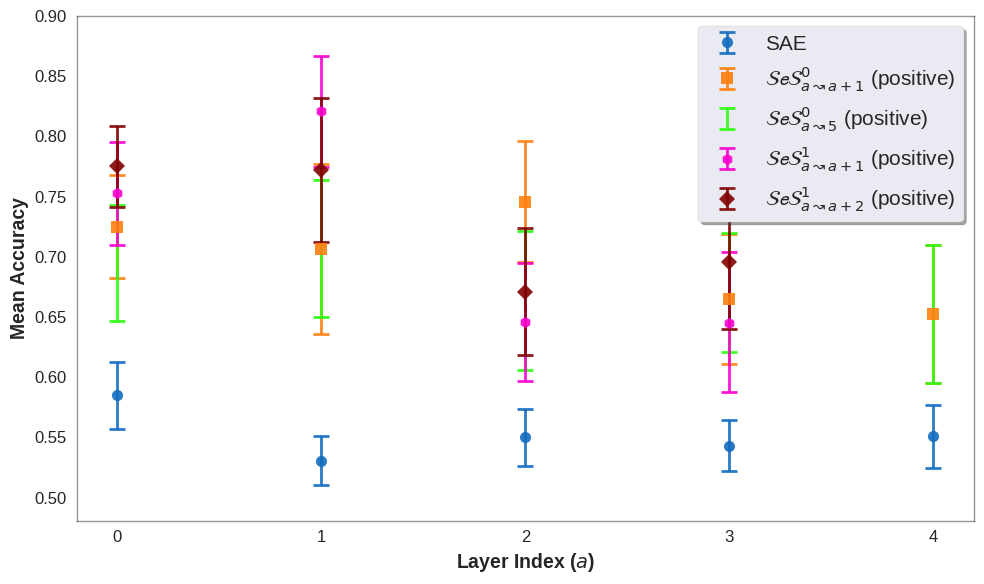

In [ ]:
# Create comparison visualizations with improved styling
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Define professional color scheme
colors = [ "#136cc0", '#ff7f0e', "#2aff0e",  "#fa00d0",   "#810202"]  # Red for SAE, Orange for SeS
markers = ['o', 's', 'x', 'h', 'D']
marker_size = 8

# Plot error bars for each data type separately
for idx, data_type in enumerate(combined_df['data_type'].unique()):
    subset = combined_df[combined_df['data_type'] == data_type]
    
    # Extract error bar values (convert from 2D array to format expected by errorbar)
    error_bars = np.array([err for err in subset['mean_interval']])
    
    # Transpose to get format expected by matplotlib: [[lower_errors], [upper_errors]]
    if len(error_bars) > 0:
        error_bars = error_bars.T
        
        # Determine color and marker based on data type
        color = colors[idx]
        marker = markers[idx]
        
        # Map LaTeX data type to simpler label for legend
        legend_label = 'SAE' if data_type == 'SAE' else data_type
        
        ax.errorbar([int(x) for x in subset['layer']], subset['mean_accuracy'], 
                   yerr=error_bars,
                   label=legend_label, 
                   marker=marker,
                   markersize=marker_size,
                   color=color,
                   capsize=6, 
                   capthick=2,
                   elinewidth=2, 
                   alpha=0.9, 
                   linestyle='')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#1111116E")
    spine.set_linewidth(1)

# Enhanced styling
ax.set_xlabel('Layer Index ($a$)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(range(5))  # Ensure all layers 0-4 are shown
ax.legend(fontsize=15, frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.99,0.99))
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_facecolor('white')

# Set axis limits for better visualization
y_min = combined_df['mean_accuracy'].min() - 0.05
y_max = 0.9#combined_df['mean_accuracy'].max() + 0.05
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig(f"../typst/figs/faith_{DIRECTION_FILTER}.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()